In [ ]:
import jax.numpy as jnp
import jax 
import matplotlib.pyplot as plt
import diffrax

print(jax.devices())

K = 40  # Number of globa-scale variables X
J = 5  # Number of local-scale Y variables per single global-scale X variable
nt = 10  # Number of time steps
dt = 0.001  # Time step
F = 10.0  # Forcing
k = jnp.arange(K)  # For coordinate in plots
j = jnp.arange(J * K)  # For coordinate in plots

def gamma(i): 
    return 0.1 + 0.25 * jnp.cos((2 * jnp.pi * i)/J)

def d_bar(i): 
    return 1.0 + 0.7 * jnp.cos((2 * jnp.pi * i)/J)

ds = jnp.zeros((K,J))
ds = ds.at[:,0].set(0.2)
ds = ds.at[:,1].set(0.5)
ds = ds.at[:,2].set(1.0)
ds = ds.at[:,3].set(2.0)
ds = ds.at[:,4].set(5.0)

[CudaDevice(id=0)]
[[0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]
 [0.2 0.5 1.  2.  5. ]]


In [ ]:
def L96(t, state, par):
    X, Y = state
    ds = par
    
    i_indices = jnp.arange(0, X.shape[0])
    F = 10
    
    gammas = gamma(i_indices)
    d_bars = d_bar(i_indices)
    
    gammas_expanded = gammas[:,None]
    X_expanded = X[:, None]
    

    Xdot = (
        jnp.roll(X, 1) * (jnp.roll(X, -1) - jnp.roll(X, 2))
        + jnp.sum(gammas_expanded * X_expanded * Y, axis=-1)
        - d_bars * X
        + F
    )
    
    Ydot = -ds * Y - X_expanded**2

    return (Xdot, Ydot)

In [68]:
def model(ts, y0, par):
    terms = diffrax.ODETerm(L96)
    solution = diffrax.diffeqsolve(
        terms,
        diffrax.Dopri8(),
        t0=ts[0],
        t1=ts[-1],
        dt0=dt,
        y0=y0,
        args=par,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps = 100_000,
    )
    return solution.ys


In [69]:
key = jax.random.key(0)

key_x, key_y = jax.random.split(key)
scale = 0.0

X_init = jnp.zeros((K,)) + scale * jax.random.normal(key_x, shape=(K,))
Y_init = jnp.zeros((K, J)) + scale * jax.random.normal(key_y, shape=(K, J))

In [70]:
t = jnp.arange(0, nt + dt, dt)
y0 = (X_init, Y_init)

par = (ds)

X,Y = model(t, y0, par)


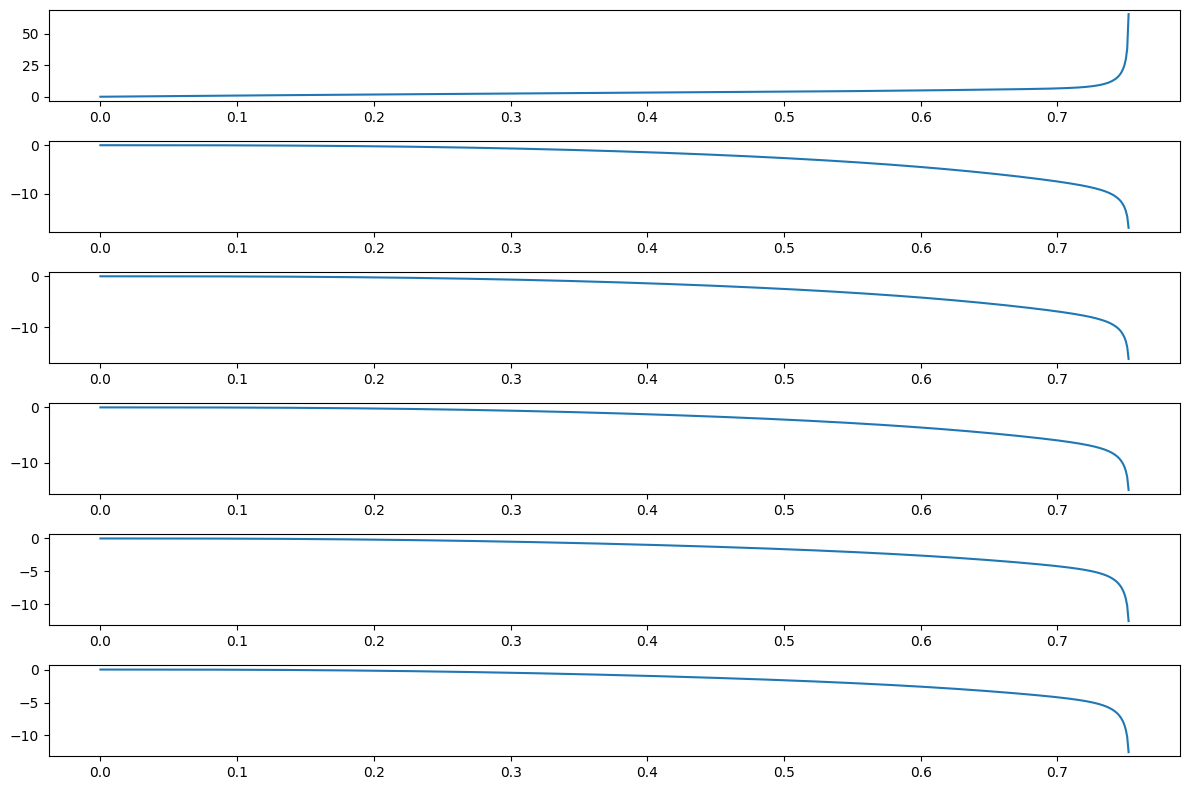

In [71]:
fig,axes = plt.subplots(6,figsize = (12,8))

index = 21

axes[0].plot(t,X[:,21])
for j in range(1,6): 
    axes[j].plot(t,Y[:,index,j])
fig.set_tight_layout('constrained')
plt.show()